# Trabajo Practico 1

## EDA sobre DJBR de la CGR

**Nombre:** Adrian Aguero  
**Materia:** Introduccion a la Ciencia de Datos  
**Fecha:** 07/04/2026

Este notebook desarrolla un analisis exploratorio de datos sobre una muestra didactica de declaraciones juradas de bienes y rentas (DJBR) de la Contraloria General de la Republica (CGR).

## Objetivo
- Comprender que representan los datos y que decisiones pueden apoyar.
- Limpiar el dataset `raw` para obtener una base analizable.
- Realizar EDA univariado y bivariado con visualizaciones.
- Detectar anomalias y construir el indicador `indice_riqueza = activos_gs / ingreso_mensual_gs`.


## Comprension del problema

Los datos representan declaraciones patrimoniales de funcionarios publicos: activos, pasivos, patrimonio neto, ingresos, egresos, institucion, cargo, tipo de presentacion y anio.

Con este analisis se pueden apoyar decisiones como:
- identificar perfiles patrimoniales atipicos que ameriten revision;
- comparar instituciones o tipos de presentacion;
- priorizar auditorias o controles segun concentracion de riqueza o dispersion;
- evaluar calidad de los datos y necesidades de estandarizacion.


In [1]:
# Si trabajas en Colab y faltan librerias, descomenta la siguiente linea
# !pip install pandas matplotlib seaborn

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [2]:
github_base_url = 'https://raw.githubusercontent.com/afaraldo/maestria-de-datos-ucom/main/ciencia-de-datos/TrabajoPractico1'

raw_path = f'{github_base_url}/cgr_djbr_muestra_taller_raw.csv'
clean_reference_path = f'{github_base_url}/cgr_djbr_muestra_taller_clean.csv'
dictionary_path = f'{github_base_url}/diccionario_datos_cgr_djbr.csv'

local_project_dir = Path('ciencia-de-datos/TrabajoPractico1')
project_dir = local_project_dir if local_project_dir.exists() else Path.cwd()
visualizations_dir = project_dir / 'visualizaciones'
visualizations_dir.mkdir(parents=True, exist_ok=True)

print('Cargando archivos directamente desde GitHub...')

df_raw = pd.read_csv(raw_path)
data_dictionary = pd.read_csv(dictionary_path)

print(f'Dimensiones raw: {df_raw.shape}')
display(data_dictionary)
display(df_raw.head())


Cargando archivos directamente desde GitHub...
Dimensiones raw: (246, 15)


,variable,descripcion,tipo,nota
0,registro_id,Identificador interno de la muestra didáctica,texto,No oficial
1,cedula,Identificador de persona. En muestra didáctica...,texto,No usar como clave pública
2,funcionario,Nombre o identificador del funcionario,texto,En muestra didáctica es anónimo
3,anio,Año de la declaración,entero,Útil para series temporales
4,tipo_presentacion,Motivo o tipo de la declaración,texto,"Ej. actualización, asunción, renovación"
5,institucion,Institución principal del funcionario,texto,Variable categórica clave para EDA
6,cargo,Cargo o rol,texto,Puede tener valores faltantes en raw
7,activos_gs,Total de activos declarados,numérico,Guaraníes
8,pasivos_gs,Total de pasivos declarados,numérico,Guaraníes
9,patrimonio_neto_gs,Activos - pasivos,numérico,Guaraníes


,registro_id,cedula,funcionario,anio,tipo_presentacion,institucion,cargo,activos_gs,pasivos_gs,patrimonio_neto_gs,ingreso_mensual_gs,ingreso_anual_gs,egreso_mensual_gs,egreso_anual_gs,fuente
0,REG-100000,1329365,FUNCIONARIO_001,2018,RENOVACION DE CONTRATO,Municipalidad de Asunción,Director/a,"10.450.421,88","0,00","10.450.421,88","7.404.019,76","7.404.019,76","4.505.193,91","3.253.621,83",Muestra didáctica inspirada en campos visibles...
1,REG-100001,2500942,FUNCIONARIO_002,2018,ASUNCION AL CARGO,Municipalidad de Asunción,Chofer,"10.230.670,78","3.188.590,87","7.042.079,91","18.116.820,55","0,00","6.704.423,57","10.608.585,72",Muestra didáctica inspirada en campos visibles...
2,REG-100002,4385659,FUNCIONARIO_003,2022,ASUNCION AL CARGO,Instituto de Previsión Social,Enfermero/a,"5.186.327,71","2.216.252,32","2.970.075,39","6.769.831,95","0,00","2.558.808,17","3.871.579,19",Muestra didáctica inspirada en campos visibles...
3,REG-100003,3055555,FUNCIONARIO_004,2019,ACTUALIZACION,Poder Judicial,Auxiliar jurisdiccional,"61.261.763,32","0,00","61.261.763,32","4.325.185,08","0,00","1.852.742,84",NaN,Muestra didáctica inspirada en campos visibles...
4,REG-100004,4613009,FUNCIONARIO_005,2024,ASUNCION AL CARGO,Municipalidad de Asunción,Fiscalizador/a,"1.690.858,73","0,00","1.690.858,73","15.521.937,29","0,00","7.604.073,56","4.094.260,35",Muestra didáctica inspirada en campos visibles...


## Exploracion inicial

Se revisan estructura, tipos y calidad inicial del dataset.


In [3]:
display(df_raw.info())
display(df_raw.isna().sum().sort_values(ascending=False).to_frame('nulos'))
print(f'Duplicados exactos: {df_raw.duplicated().sum()}')
display(df_raw.describe(include='all').T.head(15))


<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   registro_id         246 non-null    str  
 1   cedula              246 non-null    int64
 2   funcionario         246 non-null    str  
 3   anio                246 non-null    int64
 4   tipo_presentacion   242 non-null    str  
 5   institucion         246 non-null    str  
 6   cargo               242 non-null    str  
 7   activos_gs          246 non-null    str  
 8   pasivos_gs          246 non-null    str  
 9   patrimonio_neto_gs  246 non-null    str  
 10  ingreso_mensual_gs  246 non-null    str  
 11  ingreso_anual_gs    246 non-null    str  
 12  egreso_mensual_gs   246 non-null    str  
 13  egreso_anual_gs     128 non-null    str  
 14  fuente              246 non-null    str  
dtypes: int64(2), str(13)
memory usage: 29.0 KB


None

,nulos
egreso_anual_gs,118
cargo,4
tipo_presentacion,4
funcionario,0
cedula,0
anio,0
registro_id,0
institucion,0
activos_gs,0
patrimonio_neto_gs,0


Duplicados exactos: 6


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
registro_id,246,240,REG-100003,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cedula,246.00,NaN,NaN,NaN,"3,134,354.36","1,137,180.93","1,010,699.00","2,089,458.50","3,265,985.00","4,093,755.50","4,978,400.00"
funcionario,246,240,FUNCIONARIO_004,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anio,246.00,NaN,NaN,NaN,"2,021.00",2.01,"2,018.00","2,019.00","2,021.00","2,023.00","2,024.00"
tipo_presentacion,242,5,ACTUALIZACION,79,NaN,NaN,NaN,NaN,NaN,NaN,NaN
institucion,246,17,Ministerio de Salud Pública y Bienestar Social,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cargo,242,20,Administrativo/a,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
activos_gs,246,240,"61.261.763,32",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pasivos_gs,246,180,"0,00",63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patrimonio_neto_gs,246,240,"61.261.763,32",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Limpieza de datos

Se trabaja desde el archivo `raw` para que la limpieza sea reproducible. A continuacion, la limpieza queda separada en pasos numerados.


In [4]:
text_columns = ['registro_id', 'cedula', 'funcionario', 'tipo_presentacion', 'institucion', 'cargo', 'fuente']
numeric_columns = [
    'activos_gs',
    'pasivos_gs',
    'patrimonio_neto_gs',
    'ingreso_mensual_gs',
    'ingreso_anual_gs',
    'egreso_mensual_gs',
    'egreso_anual_gs',
]

def parse_local_decimal(series):
    cleaned = (
        series.astype(str)
        .str.strip()
        .replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    return pd.to_numeric(cleaned, errors='coerce')

df = df_raw.copy()


### 1. Eliminacion de duplicados

Se remueven filas completamente repetidas para evitar sesgos en el analisis.


In [5]:
df = df.drop_duplicates().reset_index(drop=True)
print(f'Forma luego de eliminar duplicados: {df.shape}')

Forma luego de eliminar duplicados: (240, 15)


### 2. Normalizacion de columnas de texto

Se limpian espacios sobrantes y se completan faltantes categoricos con `No especificado`.


In [6]:
for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

df['tipo_presentacion'] = df['tipo_presentacion'].replace({'nan': np.nan}).fillna('No especificado')
df['cargo'] = df['cargo'].replace({'nan': np.nan}).fillna('No especificado')
print(f'Forma luego de normalizar texto: {df.shape}')


Forma luego de normalizar texto: (240, 15)


### 3. Conversion de montos y relleno de nulos numericos

Los montos se convierten desde formato local a numerico y luego los faltantes en columnas numericas se reemplazan por `0`.


In [7]:
for col in numeric_columns:
    df[col] = parse_local_decimal(df[col])

df[numeric_columns] = df[numeric_columns].fillna(0)
df['anio'] = pd.to_numeric(df['anio'], errors='coerce').astype('Int64')
print(f'Forma luego de convertir tipos y completar nulos: {df.shape}')


Forma luego de convertir tipos y completar nulos: (240, 15)


### 4. Outliers

Se identifican outliers en las variables numericas con el criterio IQR y luego se eliminan del `dataframe` antes del analisis.


In [8]:
def outlier_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_report_cleaning = []
outlier_mask = pd.Series(False, index=df.index)
for col in numeric_columns:
    lower, upper = outlier_bounds(df[col].dropna())
    col_mask = df[col].lt(lower) | df[col].gt(upper)
    outlier_mask |= col_mask
    outlier_report_cleaning.append({
        'variable': col,
        'limite_inferior': lower,
        'limite_superior': upper,
        'cantidad_outliers': int(col_mask.sum()),
    })

outliers_eliminados = int(outlier_mask.sum())
df = df.loc[~outlier_mask].reset_index(drop=True)

display(pd.DataFrame(outlier_report_cleaning))
print(f'Filas eliminadas por outliers: {outliers_eliminados}')
print(f'Forma luego de eliminar outliers: {df.shape}')


,variable,limite_inferior,limite_superior,cantidad_outliers
0,activos_gs,"-17,261,799.34","42,402,577.08",31
1,pasivos_gs,"-4,726,909.31","7,878,182.18",25
2,patrimonio_neto_gs,"-16,280,730.08","37,202,577.15",28
3,ingreso_mensual_gs,"249,172.64","11,180,015.41",15
4,ingreso_anual_gs,"-7,530,827.02","12,551,378.38",2
5,egreso_mensual_gs,"-383,250.70","6,888,185.18",8
6,egreso_anual_gs,"-2,401,976.71","4,003,294.51",9


Filas eliminadas por outliers: 58
Forma luego de eliminar outliers: (182, 15)


### 5. Control de calidad

Se comparan metricas basicas entre la base original y la base limpia para verificar el resultado final de la limpieza.


In [9]:
quality_summary = pd.DataFrame({
    'raw': {
        'filas': len(df_raw),
        'duplicados': int(df_raw.duplicated().sum()),
        'nulos_tipo_presentacion': int(df_raw['tipo_presentacion'].isna().sum()),
        'nulos_cargo': int(df_raw['cargo'].isna().sum()),
        'nulos_numericos': int(df_raw[numeric_columns].isna().sum().sum()),
    },
    'clean_reproducido': {
        'filas': len(df),
        'duplicados': int(df.duplicated().sum()),
        'nulos_tipo_presentacion': int(df['tipo_presentacion'].isna().sum()),
        'nulos_cargo': int(df['cargo'].isna().sum()),
        'nulos_numericos': int(df[numeric_columns].isna().sum().sum()),
        'outliers_eliminados': outliers_eliminados,
    }
})

print(f'Forma final luego del control de calidad: {df.shape}')
display(quality_summary)
display(df.head())


Forma final luego del control de calidad: (182, 15)


,raw,clean_reproducido
filas,246.00,182
duplicados,6.00,0
nulos_tipo_presentacion,4.00,0
nulos_cargo,4.00,0
nulos_numericos,118.00,0
outliers_eliminados,NaN,58


,registro_id,cedula,funcionario,anio,tipo_presentacion,institucion,cargo,activos_gs,pasivos_gs,patrimonio_neto_gs,ingreso_mensual_gs,ingreso_anual_gs,egreso_mensual_gs,egreso_anual_gs,fuente
0,REG-100000,1329365,FUNCIONARIO_001,2018,RENOVACION DE CONTRATO,Municipalidad de Asunción,Director/a,"10,450,421.88",0.00,"10,450,421.88","7,404,019.76","7,404,019.76","4,505,193.91","3,253,621.83",Muestra didáctica inspirada en campos visibles...
1,REG-100002,4385659,FUNCIONARIO_003,2022,ASUNCION AL CARGO,Instituto de Previsión Social,Enfermero/a,"5,186,327.71","2,216,252.32","2,970,075.39","6,769,831.95",0.00,"2,558,808.17","3,871,579.19",Muestra didáctica inspirada en campos visibles...
2,REG-100005,2504384,FUNCIONARIO_006,2022,ASUNCION AL CARGO,Ministerio de Obras Públicas y Comunicaciones,Técnico/a,"29,182,531.09",0.00,"29,182,531.09","9,932,453.84",0.00,"5,284,687.58",0.00,Muestra didáctica inspirada en campos visibles...
3,REG-100006,4521441,FUNCIONARIO_007,2018,ACTUALIZACION,ESSAP,Administrativo/a,"13,363,091.64",0.00,"13,363,091.64","4,651,977.53","4,651,977.53","2,875,006.75",0.00,Muestra didáctica inspirada en campos visibles...
4,REG-100007,1214020,FUNCIONARIO_008,2020,RENOVACION DE CONTRATO,Ministerio de Salud Pública y Bienestar Social,Chofer,"3,705,335.35","1,118,899.78","2,586,435.57","5,121,548.56",0.00,"3,932,510.39","2,647,341.78",Muestra didáctica inspirada en campos visibles...


## EDA


### Estadistica descriptiva

Se resume la distribucion de las variables numericas principales y la composicion del dataset por institucion, tipo de presentacion y anio.


In [10]:
summary = df[numeric_columns].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T
show_columns = ['mean', '50%', 'std', 'min', 'max']
display(summary)
display(summary[show_columns].rename(columns={'mean': 'promedio', '50%': 'mediana', 'std': 'desvio'}))

top_instituciones = df['institucion'].value_counts().head(10)
tipo_counts = df['tipo_presentacion'].value_counts()
anio_counts = df['anio'].value_counts().sort_index()

display(top_instituciones.to_frame('cantidad'))
display(tipo_counts.to_frame('cantidad'))
display(anio_counts.to_frame('cantidad'))


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
activos_gs,182.00,"9,909,028.15","7,426,870.28","276,746.33","4,582,835.91","7,803,896.96","14,117,671.40","20,310,041.40","25,482,656.88","29,860,548.46","35,517,709.35"
pasivos_gs,182.00,"1,405,606.88","1,778,147.71",0.00,0.00,"645,103.91","2,020,756.35","4,167,914.05","5,374,979.28","6,766,874.63","7,601,697.04"
patrimonio_neto_gs,182.00,"8,503,421.27","7,103,673.63","217,196.87","3,107,890.31","6,347,299.54","11,750,087.42","18,679,554.95","22,372,387.93","29,860,548.46","35,517,709.35"
ingreso_mensual_gs,182.00,"5,420,059.16","1,926,854.49","1,200,000.00","4,087,805.55","5,256,355.24","6,495,223.95","7,759,678.83","9,080,471.62","10,717,734.26","11,026,475.09"
ingreso_anual_gs,182.00,"2,232,722.92","2,885,353.51",0.00,0.00,0.00,"4,796,503.58","6,181,968.55","7,118,894.01","9,391,353.86","10,748,698.48"
egreso_mensual_gs,182.00,"3,046,195.18","1,246,041.73","613,300.11","2,178,785.12","2,873,843.94","3,909,289.86","4,762,066.97","5,351,929.33","5,991,398.19","6,046,976.06"
egreso_anual_gs,182.00,"807,911.03","1,062,778.00",0.00,0.00,"269,879.66","1,448,720.40","2,643,186.49","3,012,925.53","3,514,243.47","3,871,579.19"


,promedio,mediana,desvio,min,max
activos_gs,"9,909,028.15","7,803,896.96","7,426,870.28","276,746.33","35,517,709.35"
pasivos_gs,"1,405,606.88","645,103.91","1,778,147.71",0.00,"7,601,697.04"
patrimonio_neto_gs,"8,503,421.27","6,347,299.54","7,103,673.63","217,196.87","35,517,709.35"
ingreso_mensual_gs,"5,420,059.16","5,256,355.24","1,926,854.49","1,200,000.00","11,026,475.09"
ingreso_anual_gs,"2,232,722.92",0.00,"2,885,353.51",0.00,"10,748,698.48"
egreso_mensual_gs,"3,046,195.18","2,873,843.94","1,246,041.73","613,300.11","6,046,976.06"
egreso_anual_gs,"807,911.03","269,879.66","1,062,778.00",0.00,"3,871,579.19"


,cantidad
institucion,
Ministerio de Salud Pública y Bienestar Social,38
Ministerio de Educación y Ciencias,31
Instituto de Previsión Social,25
ESSAP,17
Universidad Nacional de Asunción,15
Ministerio de Obras Públicas y Comunicaciones,14
Municipalidad de Asunción,11
Gobernación de Central,11
Poder Judicial,8


,cantidad
tipo_presentacion,
ACTUALIZACION,56
ASUNCION AL CARGO,51
RENOVACION DE CONTRATO,27
OTRO,27
CESE,17
No especificado,4


,cantidad
anio,
2018,22
2019,35
2020,26
2021,27
2022,25
2023,20
2024,27


### Analisis univariado

Se revisan variables individuales para entender dispersion, asimetria y concentracion de observaciones antes de comparar relaciones entre columnas.


In [11]:
univariate_summary = pd.DataFrame({
    'variable': ['activos_gs', 'patrimonio_neto_gs', 'ingreso_mensual_gs'],
    'mediana': [df['activos_gs'].median(), df['patrimonio_neto_gs'].median(), df['ingreso_mensual_gs'].median()],
    'promedio': [df['activos_gs'].mean(), df['patrimonio_neto_gs'].mean(), df['ingreso_mensual_gs'].mean()],
    'asimetria': [df['activos_gs'].skew(), df['patrimonio_neto_gs'].skew(), df['ingreso_mensual_gs'].skew()],
})

display(univariate_summary)
display(top_instituciones.head(5).to_frame('cantidad'))


,variable,mediana,promedio,asimetria
0,activos_gs,"7,803,896.96","9,909,028.15",1.12
1,patrimonio_neto_gs,"6,347,299.54","8,503,421.27",1.32
2,ingreso_mensual_gs,"5,256,355.24","5,420,059.16",0.49


,cantidad
institucion,
Ministerio de Salud Pública y Bienestar Social,38
Ministerio de Educación y Ciencias,31
Instituto de Previsión Social,25
ESSAP,17
Universidad Nacional de Asunción,15


### Analisis bivariado

Se exploran relaciones entre activos, patrimonio e ingresos para verificar si el ingreso mensual acompana el nivel patrimonial declarado.


,ingreso_mensual_gs,egreso_mensual_gs,ingreso_anual_gs
activos_gs,0.26,0.16,0.12
patrimonio_neto_gs,0.27,0.18,0.13


,patrimonio_neto_gs,ingreso_mensual_gs
tipo_presentacion,,
No especificado,"9,608,070.96","5,374,778.95"
ACTUALIZACION,"6,814,956.28","5,220,211.89"
CESE,"6,063,007.01","5,354,021.53"
ASUNCION AL CARGO,"5,641,587.66","5,551,526.51"
RENOVACION DE CONTRATO,"5,455,103.88","5,826,295.61"
OTRO,"5,283,859.03","4,380,780.72"


,patrimonio_neto_gs,ingreso_mensual_gs
institucion,,
poder judicial,"31,926,150.71","10,710,471.05"
MINISTERIO DE OBRAS PÚBLICAS Y COMUNICACIONES,"17,693,259.74","4,886,792.08"
Ministerio de Economía y Finanzas,"14,540,307.29","7,588,938.37"
instituto de previsión social,"13,644,319.94","5,751,698.06"
Gobernación de Central,"12,715,639.44","6,504,736.05"
Poder Judicial,"9,711,654.51","8,173,568.59"
Ministerio de Obras Públicas y Comunicaciones,"8,090,746.41","5,819,409.25"
Universidad Nacional de Asunción,"7,915,406.55","5,386,638.88"
Municipalidad de Asunción,"7,377,294.90","7,404,019.76"


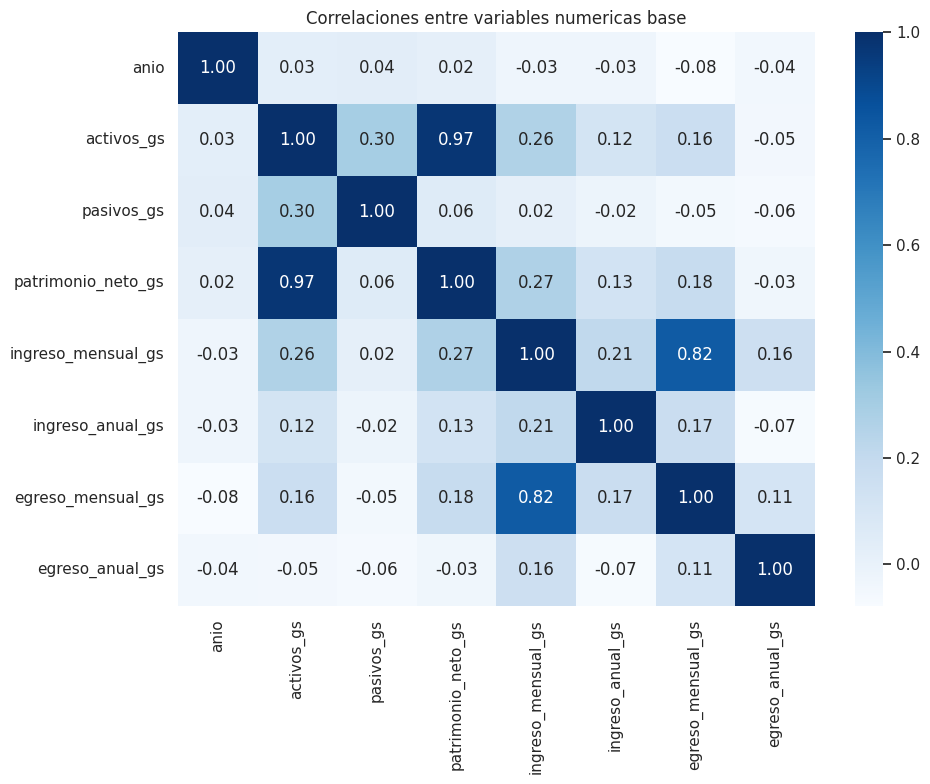

Grafico guardado en: /home/afaraldo/RubymineProjects/maestria-de-datos-ucom/ciencia-de-datos/TrabajoPractico1/visualizaciones/heatmap_correlaciones.png


In [12]:
corr = df[['anio'] + numeric_columns].corr(numeric_only=True)
correlaciones_clave = corr.loc[
    ['activos_gs', 'patrimonio_neto_gs'],
    ['ingreso_mensual_gs', 'egreso_mensual_gs', 'ingreso_anual_gs']
]

display(correlaciones_clave)

median_by_type = (
    df.groupby('tipo_presentacion')[['patrimonio_neto_gs', 'ingreso_mensual_gs']]
    .median()
    .sort_values('patrimonio_neto_gs', ascending=False)
)
median_by_institucion = (
    df.groupby('institucion')[['patrimonio_neto_gs', 'ingreso_mensual_gs']]
    .median()
    .sort_values('patrimonio_neto_gs', ascending=False)
    .head(10)
)

display(median_by_type)
display(median_by_institucion)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlaciones entre variables numericas base')
plt.tight_layout()
heatmap_path = visualizations_dir / 'heatmap_correlaciones.png'
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Grafico guardado en: {heatmap_path}')


## Visualizacion

Las visualizaciones se generan, se guardan en archivos dentro de `visualizaciones/` y tambien se muestran incrustadas en este notebook al ejecutarlo.


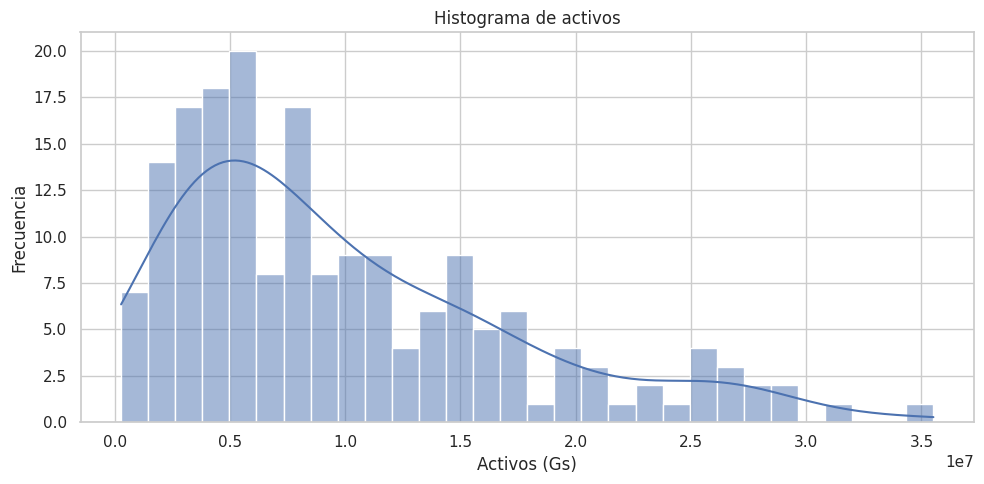

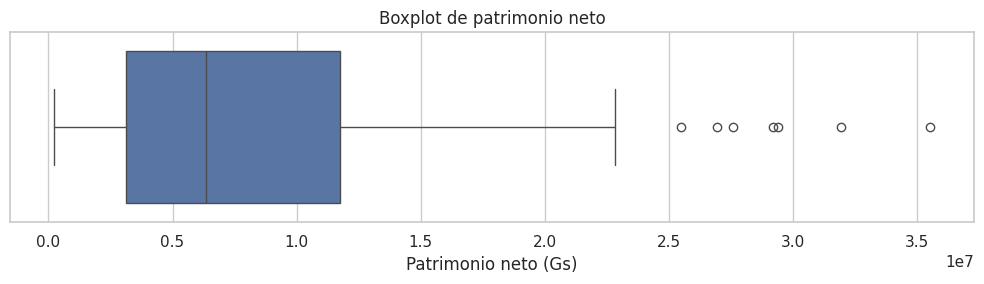

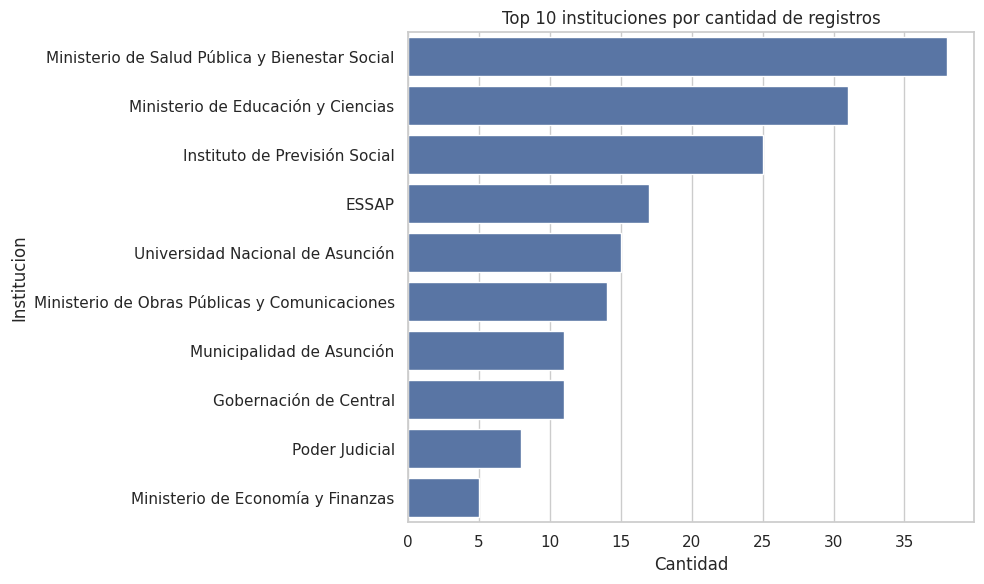

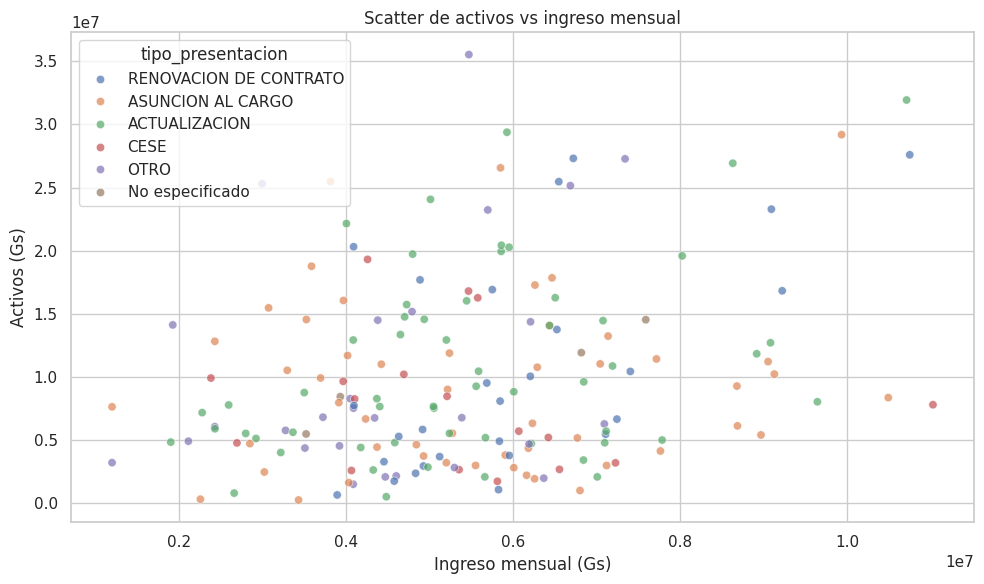

Grafico guardado en: /home/afaraldo/RubymineProjects/maestria-de-datos-ucom/ciencia-de-datos/TrabajoPractico1/visualizaciones/histograma_activos.png
Grafico guardado en: /home/afaraldo/RubymineProjects/maestria-de-datos-ucom/ciencia-de-datos/TrabajoPractico1/visualizaciones/boxplot_patrimonio.png
Grafico guardado en: /home/afaraldo/RubymineProjects/maestria-de-datos-ucom/ciencia-de-datos/TrabajoPractico1/visualizaciones/barras_instituciones.png
Grafico guardado en: /home/afaraldo/RubymineProjects/maestria-de-datos-ucom/ciencia-de-datos/TrabajoPractico1/visualizaciones/scatter_activos_ingresos.png


In [13]:
saved_visualizations = []

plt.figure(figsize=(10, 5))
sns.histplot(df['activos_gs'], bins=30, kde=True)
plt.title('Histograma de activos')
plt.xlabel('Activos (Gs)')
plt.ylabel('Frecuencia')
plt.tight_layout()
hist_path = visualizations_dir / 'histograma_activos.png'
plt.savefig(hist_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
saved_visualizations.append(hist_path)

plt.figure(figsize=(10, 3))
sns.boxplot(x=df['patrimonio_neto_gs'])
plt.title('Boxplot de patrimonio neto')
plt.xlabel('Patrimonio neto (Gs)')
plt.tight_layout()
boxplot_path = visualizations_dir / 'boxplot_patrimonio.png'
plt.savefig(boxplot_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
saved_visualizations.append(boxplot_path)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_instituciones.values, y=top_instituciones.index)
plt.title('Top 10 instituciones por cantidad de registros')
plt.xlabel('Cantidad')
plt.ylabel('Institucion')
plt.tight_layout()
barplot_path = visualizations_dir / 'barras_instituciones.png'
plt.savefig(barplot_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
saved_visualizations.append(barplot_path)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ingreso_mensual_gs', y='activos_gs', hue='tipo_presentacion', alpha=0.7)
plt.title('Scatter de activos vs ingreso mensual')
plt.xlabel('Ingreso mensual (Gs)')
plt.ylabel('Activos (Gs)')
plt.tight_layout()
scatter_path = visualizations_dir / 'scatter_activos_ingresos.png'
plt.savefig(scatter_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
saved_visualizations.append(scatter_path)

for saved_path in saved_visualizations:
    print(f'Grafico guardado en: {saved_path}')


## Anomalias

Se identifican valores extremos sobre variables base del dataset para detectar registros que merecen una revision puntual.


In [14]:
outlier_report = []
variables_anomalias = ['activos_gs', 'patrimonio_neto_gs', 'ingreso_mensual_gs']

for variable in variables_anomalias:
    lower, upper = outlier_bounds(df[variable].dropna())
    outliers = df[df[variable].lt(lower) | df[variable].gt(upper)]
    outlier_report.append({
        'variable': variable,
        'limite_inferior': lower,
        'limite_superior': upper,
        'cantidad_outliers': int(len(outliers)),
        'maximo': df[variable].max(),
    })

outlier_report_df = pd.DataFrame(outlier_report)
display(outlier_report_df)

outliers_activos = df[[
    'registro_id',
    'institucion',
    'cargo',
    'activos_gs',
    'patrimonio_neto_gs',
    'ingreso_mensual_gs',
]].sort_values('activos_gs', ascending=False).head(10)
display(outliers_activos)


,variable,limite_inferior,limite_superior,cantidad_outliers,maximo
0,activos_gs,"-9,719,417.34","28,419,924.65",4,"35,517,709.35"
1,patrimonio_neto_gs,"-9,855,405.35","24,713,383.08",7,"35,517,709.35"
2,ingreso_mensual_gs,"476,677.95","10,106,351.55",4,"11,026,475.09"


,registro_id,institucion,cargo,activos_gs,patrimonio_neto_gs,ingreso_mensual_gs
35,REG-100046,Ministerio de Economía y Finanzas,Director/a,"35,517,709.35","35,517,709.35","5,471,230.92"
166,REG-100220,poder judicial,Secretario/a,"31,926,150.71","31,926,150.71","10,710,471.05"
173,REG-100229,Ministerio de Salud Pública y Bienestar Social,Técnico/a,"29,376,024.47","29,376,024.47","5,927,160.48"
2,REG-100005,Ministerio de Obras Públicas y Comunicaciones,Técnico/a,"29,182,531.09","29,182,531.09","9,932,453.84"
112,REG-100148,Poder Judicial,Actuario/a,"27,589,356.93","27,589,356.93","10,748,698.48"
119,REG-100159,Ministerio de Salud Pública y Bienestar Social,No especificado,"27,308,385.10","22,258,587.93","6,721,306.83"
48,REG-100061,Gobernación de Central,Técnico/a,"27,269,455.24","22,490,034.02","7,340,974.01"
147,REG-100193,Poder Judicial,Actuario/a,"26,924,641.80","26,924,641.80","8,630,534.60"
150,REG-100199,Municipalidad de Asunción,Chofer,"26,556,912.40","22,804,278.18","5,850,073.69"
14,REG-100019,Ministerio de Salud Pública y Bienestar Social,Chofer,"25,483,651.29","25,483,651.29","3,815,331.77"


## Indicadores

Se construye el indicador final solicitado: `indice_riqueza = bienes / ingresos`, usando `activos_gs / ingreso_mensual_gs` cuando el ingreso mensual es mayor a cero.


,indice_riqueza
count,182.00
mean,1.98
std,1.53
min,0.08
25%,0.76
50%,1.67
75%,2.76
90%,4.06
95%,4.96
99%,6.80


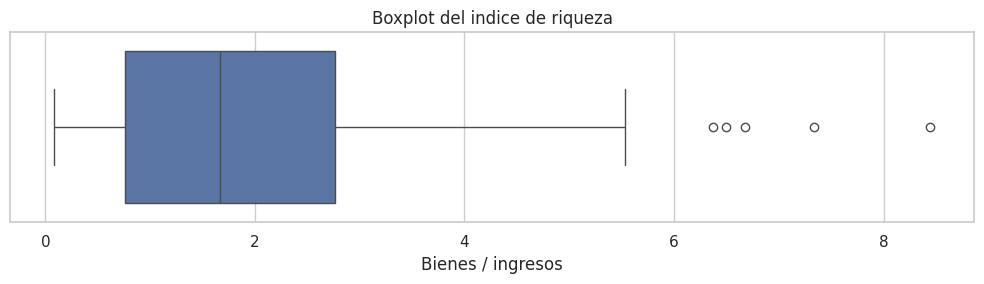

Grafico guardado en: /home/afaraldo/RubymineProjects/maestria-de-datos-ucom/ciencia-de-datos/TrabajoPractico1/visualizaciones/boxplot_indice_riqueza.png


,variable,limite_inferior,limite_superior,cantidad_outliers,maximo
0,indice_riqueza,-2.23,5.76,5,8.45


,registro_id,institucion,cargo,activos_gs,ingreso_mensual_gs,indice_riqueza
33,REG-100044,ESSAP,Seguridad,"25,294,274.09","2,995,095.31",8.45
96,REG-100129,ESSAP,Seguridad,"14,128,752.90","1,926,946.80",7.33
14,REG-100019,Ministerio de Salud Pública y Bienestar Social,Chofer,"25,483,651.29","3,815,331.77",6.68
35,REG-100046,Ministerio de Economía y Finanzas,Director/a,"35,517,709.35","5,471,230.92",6.49
39,REG-100050,Ministerio de Obras Públicas y Comunicaciones,Técnico/a,"7,647,065.89","1,200,000.00",6.37
145,REG-100191,Ministerio de Educación y Ciencias,Técnico/a,"22,147,605.49","4,005,490.75",5.53
154,REG-100204,Ministerio de Educación y Ciencias,Supervisor/a,"12,830,375.34","2,430,448.84",5.28
165,REG-100219,Instituto de Previsión Social,Técnico/a,"18,773,477.59","3,587,596.06",5.23
69,REG-100093,Instituto de Previsión Social,Enfermero/a,"15,480,283.80","3,074,114.65",5.04
132,REG-100173,ESSAP,Seguridad,"20,313,903.52","4,091,350.60",4.97


In [15]:
df['indice_riqueza'] = np.where(df['ingreso_mensual_gs'] > 0, df['activos_gs'] / df['ingreso_mensual_gs'], np.nan)

indice_summary = df['indice_riqueza'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame('indice_riqueza')
display(indice_summary)

plt.figure(figsize=(10, 3))
sns.boxplot(x=df['indice_riqueza'])
plt.title('Boxplot del indice de riqueza')
plt.xlabel('Bienes / ingresos')
plt.tight_layout()
indice_boxplot_path = visualizations_dir / 'boxplot_indice_riqueza.png'
plt.savefig(indice_boxplot_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Grafico guardado en: {indice_boxplot_path}')

lower_indice, upper_indice = outlier_bounds(df['indice_riqueza'].dropna())
outliers_indice_riqueza = df[df['indice_riqueza'].lt(lower_indice) | df['indice_riqueza'].gt(upper_indice)]

display(pd.DataFrame([{
    'variable': 'indice_riqueza',
    'limite_inferior': lower_indice,
    'limite_superior': upper_indice,
    'cantidad_outliers': int(len(outliers_indice_riqueza)),
    'maximo': df['indice_riqueza'].max(),
}]))

top_indice_riqueza = df[[
    'registro_id',
    'institucion',
    'cargo',
    'activos_gs',
    'ingreso_mensual_gs',
    'indice_riqueza',
]].sort_values('indice_riqueza', ascending=False).head(10)
display(top_indice_riqueza)


## Informe

El analisis realizado muestra que la base de datos requeria un proceso previo de limpieza para garantizar resultados consistentes, debido a la presencia de duplicados, valores faltantes y valores atipicos. Una vez depurada, la muestra permitio identificar patrones relevantes en la composicion patrimonial y de ingresos declarados.

En primer lugar, se observa que las variables patrimoniales, especialmente `activos_gs` y `patrimonio_neto_gs`, presentan una distribucion sesgada hacia la derecha. Esto indica que la mayor parte de los registros se concentra en niveles medios o bajos, mientras que un grupo reducido acumula montos considerablemente mas altos.

En segundo lugar, la relacion entre el ingreso mensual y las variables patrimoniales es baja, lo que sugiere que el nivel de activos o patrimonio neto no puede explicarse unicamente a partir del ingreso corriente declarado. Este resultado refuerza la necesidad de analizar los registros desde una perspectiva mas amplia y no solo salarial.

Tambien se identifican diferencias segun el tipo de presentacion y la institucion declarada, lo que permite reconocer perfiles distintos dentro del conjunto analizado. Esto resulta util para futuras segmentaciones o revisiones focalizadas.

Por ultimo, la construccion del `indice_riqueza` permitio detectar casos con niveles de bienes relativamente altos en comparacion con el ingreso mensual, funcionando como un indicador complementario para senalar observaciones que merecen una revision mas detallada.

## Recomendaciones

- Revisar manualmente los casos con mayor `indice_riqueza`.
- Fortalecer la normalizacion de variables categoricas como `institucion` y `cargo`.
- Evaluar con mayor cuidado las variables anuales, debido a su alta presencia de ceros o faltantes.
- Mantener un flujo de limpieza reproducible como paso obligatorio antes de cualquier analisis posterior.
